In [2]:
from utils import * 
import networkx as nx
import matplotlib.pyplot as plt
import random

In [3]:
G1, G2, B1, B2 = find_not_good_pair(N=5000,num_vertex=4,num_confounding=3)

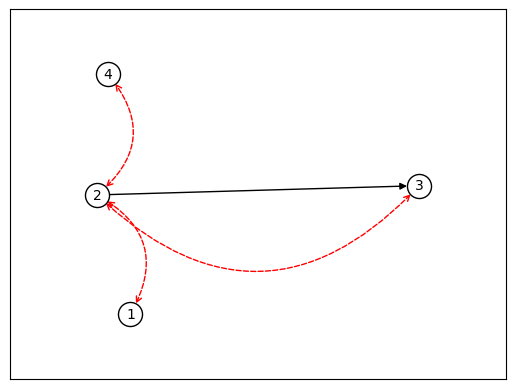

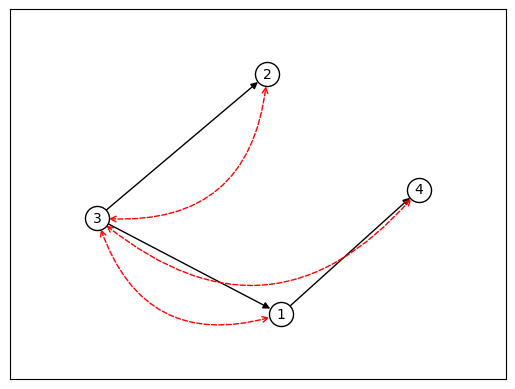

In [4]:
G1.edges, G2.edges
plot_admg(G1,B1)
plot_admg(G2,B2)

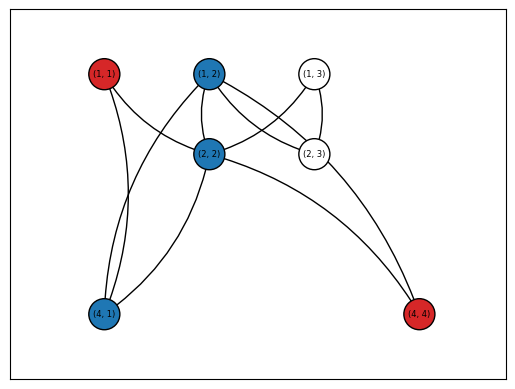

False

In [5]:
plot_auxiliary(G1,G2,B1,B2)

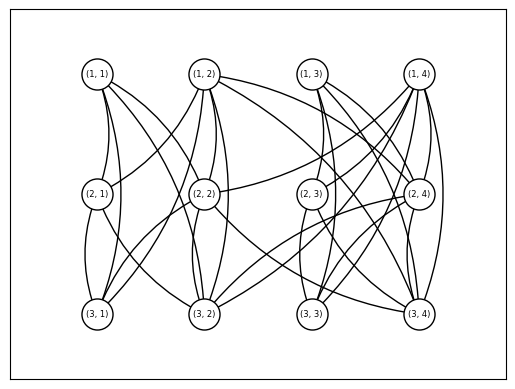

In [320]:
V = list(G1.nodes())
IG = induced_graph(V, B1, B2)
IG_cleaned = IG_clean_up(IG, G1, G2, B2)
unremovable = get_removable(V, G1, G2, B2)[1] & IG_cleaned.nodes
unremovable_neighbors = neighbors_of_set(IG_cleaned, unremovable)

remain = IG_cleaned.nodes - unremovable - unremovable_neighbors
IG_remain = IG_cleaned.subgraph(remain).copy()
IG_remain.remove_nodes_from(list(nx.isolates(IG_remain)))

options = {
"font_size": 6,
"node_size": 500,
"edgecolors": "black",
"node_color": "white",
"linewidths": 1,
"width": 1,
}
pos = {(i, j): (j, i) for i, j in IG_remain.nodes()}
nx.draw_networkx(IG_remain, pos, arrows=True, **options, connectionstyle="arc3,rad=0.2")
plt.gca().invert_yaxis()
ax = plt.gca()
ax.margins(0.20)
plt.show()


In [294]:
P = powerset(IG_remain.nodes())
covers = inclusive_minimal_covers(IG_remain,P)
covers

[{(2, 1), (2, 2), (2, 4)}, {(1, 1), (1, 2), (1, 4)}]

In [307]:
i = 4
X = list(get_j(unremovable_neighbors,i)) + list(get_j(covers[1],i))
Y = list(G2.predecessors(i))
path_rank(G1, X, Y + [i]) == path_rank(G1, X, Y)

True

In [6]:
check_inclusion_full(G1,G2,B1,B2)

False